In [1]:
import torch
import torchvision.datasets as dests
import torchvision.transforms as transforms
import torch.nn.init
import matplotlib.pyplot as plt

In [2]:
# Cuda 선언
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 랜덤 시드 고정
torch.manual_seed(777)

# GPU 사용 가능일 경우 랜덤 시드 고정
if device == 'cuda':
    torch.cuda.manual_seed_all(777)
    print('cuda')

cuda


In [4]:
# 학습 파라미터 설정
learning_rate = 0.001
training_epochs = 20
batch_size = 100

In [5]:
# 데이터셋 정의 (Data Augmentation 추가)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

cifar_train = dests.CIFAR10(root ='CIFAR10_data/',
                            train = True,
                            transform= transform_train,
                            download = True)
cifar_test = dests.CIFAR10(root = 'CIFAR10_data/',
                           train = False,
                           transform= transform_test,
                           download = True)

In [6]:
data_loader = torch.utils.data.DataLoader(dataset = cifar_train,
                                          batch_size = batch_size,
                                          shuffle = True,
                                          drop_last = True)

In [7]:
# 데이터셋 크기 확인
print(f'학습 데이터 개수: {len(cifar_train)}')
print(f'테스트 데이터 개수: {len(cifar_test)}')
print(f'이미지 형태: {cifar_train[0][0].shape}')
print(f'배치 개수: {len(data_loader)}')

학습 데이터 개수: 50000
테스트 데이터 개수: 10000
이미지 형태: torch.Size([3, 32, 32])
배치 개수: 500


In [ ]:
class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.keep_prob = 0.7 # 드롭아웃 확률 (과적합 방지 강화)
        # input image 형태는 (32, 32 , 3 ) # 높이 폭 채널
        # Conv2d 로 출력채널 32개, stride = 1, padding = 1으로 convolution 후의 크기를 보정해줌
        # ReLU = Activation Function
        # MaxPool2d = Kernel size 2x2, stride 2로 down sampling ->> 출력 형태는 (16,16,32)
        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size= 3, stride= 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2, stride = 2)
        ) 
        # input 형태는 (16, 16, 32) 
        # Conv2d로 출력채널 64개
        # MaxPool2d 로 down sampling ->> 출력은 8,8,64
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size= 3, stride= 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2, stride =2)
        )
        # input는 8,8,64
        # Conv2d로 출력채널 128개
        # Maxpool2d로 down sampling ->> 출력은 4,4,128
        self.layer3 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, kernel_size= 3, stride= 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size= 2, stride= 2)
        )
        # Fully Connected Layer 1
        # input node = 4x4x128 = 2048, 출력노드는 625 
        # Drop out으로 과적합 방지, p = 0.5
        self.fc1 = torch.nn.Linear(4 * 4 * 128, 625, bias = True)
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        self.layer4 = torch.nn.Sequential(
            self.fc1,
            torch.nn.ReLU(),
            torch.nn.Dropout(p= 1- self.keep_prob)
        )

        # 최종 FC layer
        # input node = 625, 출력 10
        self.fc2 = torch.nn.Linear(625, 10, bias= True)
        torch.nn.init.xavier_uniform_(self.fc2.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        # fc layer 전에 Tensor 펼치기
        out = out.view(out.size(0),-1)
        out = self.layer4(out)
        out = self.fc2(out)
        return out

In [9]:
# 모델 정의
model = CNN().to(device)

In [10]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= learning_rate, weight_decay=1e-4)  # Weight Decay 추가

In [11]:
total_batch = len(data_loader)
print('총 배치의 수 : {}'.format(total_batch))

총 배치의 수 : 500


In [12]:
# 학습 loss 기록용 리스트
train_losses = []

for epoch in range(training_epochs):
    avg_cost = 0

    for X, Y in data_loader: # 미니 배치 단위로 꺼내온다. X는 미니 배치, Y는 레이블.
        
        X = X.to(device)
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = model(X)
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch

    # loss 기록
    train_losses.append(avg_cost.item())
    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, avg_cost))

[Epoch:    1] cost = 1.60502267
[Epoch:    2] cost = 1.25211525
[Epoch:    3] cost = 1.11308253
[Epoch:    4] cost = 1.02847946
[Epoch:    5] cost = 0.972441137
[Epoch:    6] cost = 0.927557766
[Epoch:    7] cost = 0.89683336
[Epoch:    8] cost = 0.857726634
[Epoch:    9] cost = 0.8332389
[Epoch:   10] cost = 0.809880137
[Epoch:   11] cost = 0.789697647
[Epoch:   12] cost = 0.777060509
[Epoch:   13] cost = 0.755493641
[Epoch:   14] cost = 0.748585641
[Epoch:   15] cost = 0.731604636
[Epoch:   16] cost = 0.724094629
[Epoch:   17] cost = 0.710290313
[Epoch:   18] cost = 0.707458019
[Epoch:   19] cost = 0.69559586
[Epoch:   20] cost = 0.695786059


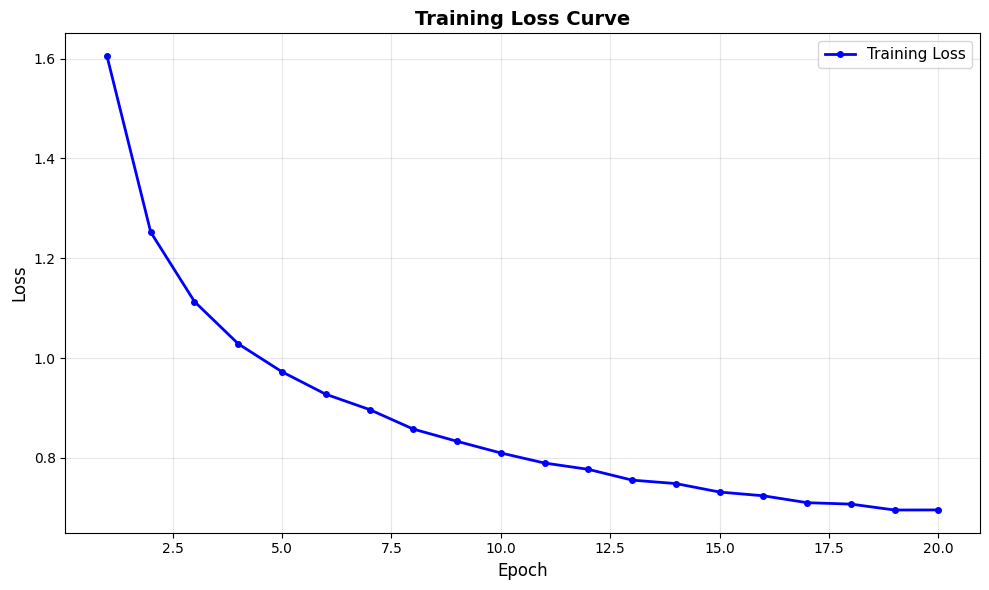


초기 Loss: 1.6050
최종 Loss: 0.6958
Loss 감소량: 0.9092


In [13]:
# 학습 곡선 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, training_epochs + 1), train_losses, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n초기 Loss: {train_losses[0]:.4f}')
print(f'최종 Loss: {train_losses[-1]:.4f}')
print(f'Loss 감소량: {train_losses[0] - train_losses[-1]:.4f}')

In [14]:
# 테스트
with torch.no_grad():
    X_test = torch.tensor(cifar_test.data).permute(0, 3, 1, 2).float().to(device)
    Y_test = torch.tensor(cifar_test.targets).to(device)

    prediction = model(X_test)

    correct_prediction = torch.argmax(prediction, 1) == Y_test 

    accuracy = correct_prediction.float().mean()
    print('Accuracy : ', accuracy.item()*100)

Accuracy :  38.830000162124634


In [ ]:
# 정확도 향상 방법
# 1. Epochs 증가
# 2. Batch size 늘리기
# 3. Data normalization
